In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

from combine_features import read_data

plt.style.use('default')

In [48]:
df = read_data("../rhea-soil-nutrient-prediction-challenge/Train.csv")
df.head()

,ID,Longitude,Latitude,Depth_cm,ph,Area,Cropland nitrogen per unit area,Cropland phosphorus per unit area,Cropland potassium per unit area,tmin_avg,...,Cu,Fe,Mg,Mn,N,P,K,Na,S,Zn
0,BF9XTB,37.65189,-3.15440,20-50,6.405,Kenya,14.202173,3.902236,-7.263155,15.240530,...,5.826,81.780,306.836,270.240,0.79,NaN,300.951,NaN,NaN,NaN
1,2RWYTR,37.63612,-3.08585,20-50,6.419,Kenya,14.202173,3.902236,-7.263155,15.240530,...,4.346,97.198,407.980,185.557,1.11,NaN,292.696,NaN,NaN,NaN
2,XZI9Q6,39.55580,-2.67218,20-50,8.388,Kenya,14.202173,3.902236,-7.263155,21.969696,...,3.657,42.672,1256.319,178.299,0.45,NaN,814.911,NaN,NaN,NaN
3,4CBCVY,39.55477,-2.67196,20-50,8.302,Kenya,14.202173,3.902236,-7.263155,21.969696,...,3.376,52.861,1322.732,464.137,0.31,NaN,815.337,NaN,NaN,NaN
4,F9GK9S,39.55477,-2.67196,20-50,8.292,Kenya,14.202173,3.902236,-7.263155,21.969696,...,3.351,46.057,1134.898,274.565,0.45,NaN,928.238,NaN,NaN,NaN


In [49]:
encoder = LabelEncoder()
df['Depth'] = encoder.fit_transform(df['Depth_cm'])
df.drop(columns=['ID', 'Depth_cm'], inplace=True)
df.dropna(axis=0, subset=['Ca', 'C_total'], inplace=True)
df.head()

,Longitude,Latitude,ph,Area,Cropland nitrogen per unit area,Cropland phosphorus per unit area,Cropland potassium per unit area,tmin_avg,tmax_avg,prec_avg,...,Fe,Mg,Mn,N,P,K,Na,S,Zn,Depth
0,37.65189,-3.15440,6.405,Kenya,14.202173,3.902236,-7.263155,15.240530,25.774622,105.626890,...,81.780,306.836,270.240,0.79,NaN,300.951,NaN,NaN,NaN,1
1,37.63612,-3.08585,6.419,Kenya,14.202173,3.902236,-7.263155,15.240530,25.774622,105.626890,...,97.198,407.980,185.557,1.11,NaN,292.696,NaN,NaN,NaN,1
2,39.55580,-2.67218,8.388,Kenya,14.202173,3.902236,-7.263155,21.969696,30.452652,63.580307,...,42.672,1256.319,178.299,0.45,NaN,814.911,NaN,NaN,NaN,1
3,39.55477,-2.67196,8.302,Kenya,14.202173,3.902236,-7.263155,21.969696,30.452652,63.580307,...,52.861,1322.732,464.137,0.31,NaN,815.337,NaN,NaN,NaN,1
4,39.55477,-2.67196,8.292,Kenya,14.202173,3.902236,-7.263155,21.969696,30.452652,63.580307,...,46.057,1134.898,274.565,0.45,NaN,928.238,NaN,NaN,NaN,1


In [50]:
target = [
    "Al",
    "B",
    "Ca",
    "Cu",
    "Fe",
    "Mg",
    "Mn",
    "N",
    "P",
    "K",
    "Na",
    "S",
    "Zn",
]
x = df.drop(columns=target, errors='ignore')
y = df['Ca']

/home/mateusz/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/mateusz/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


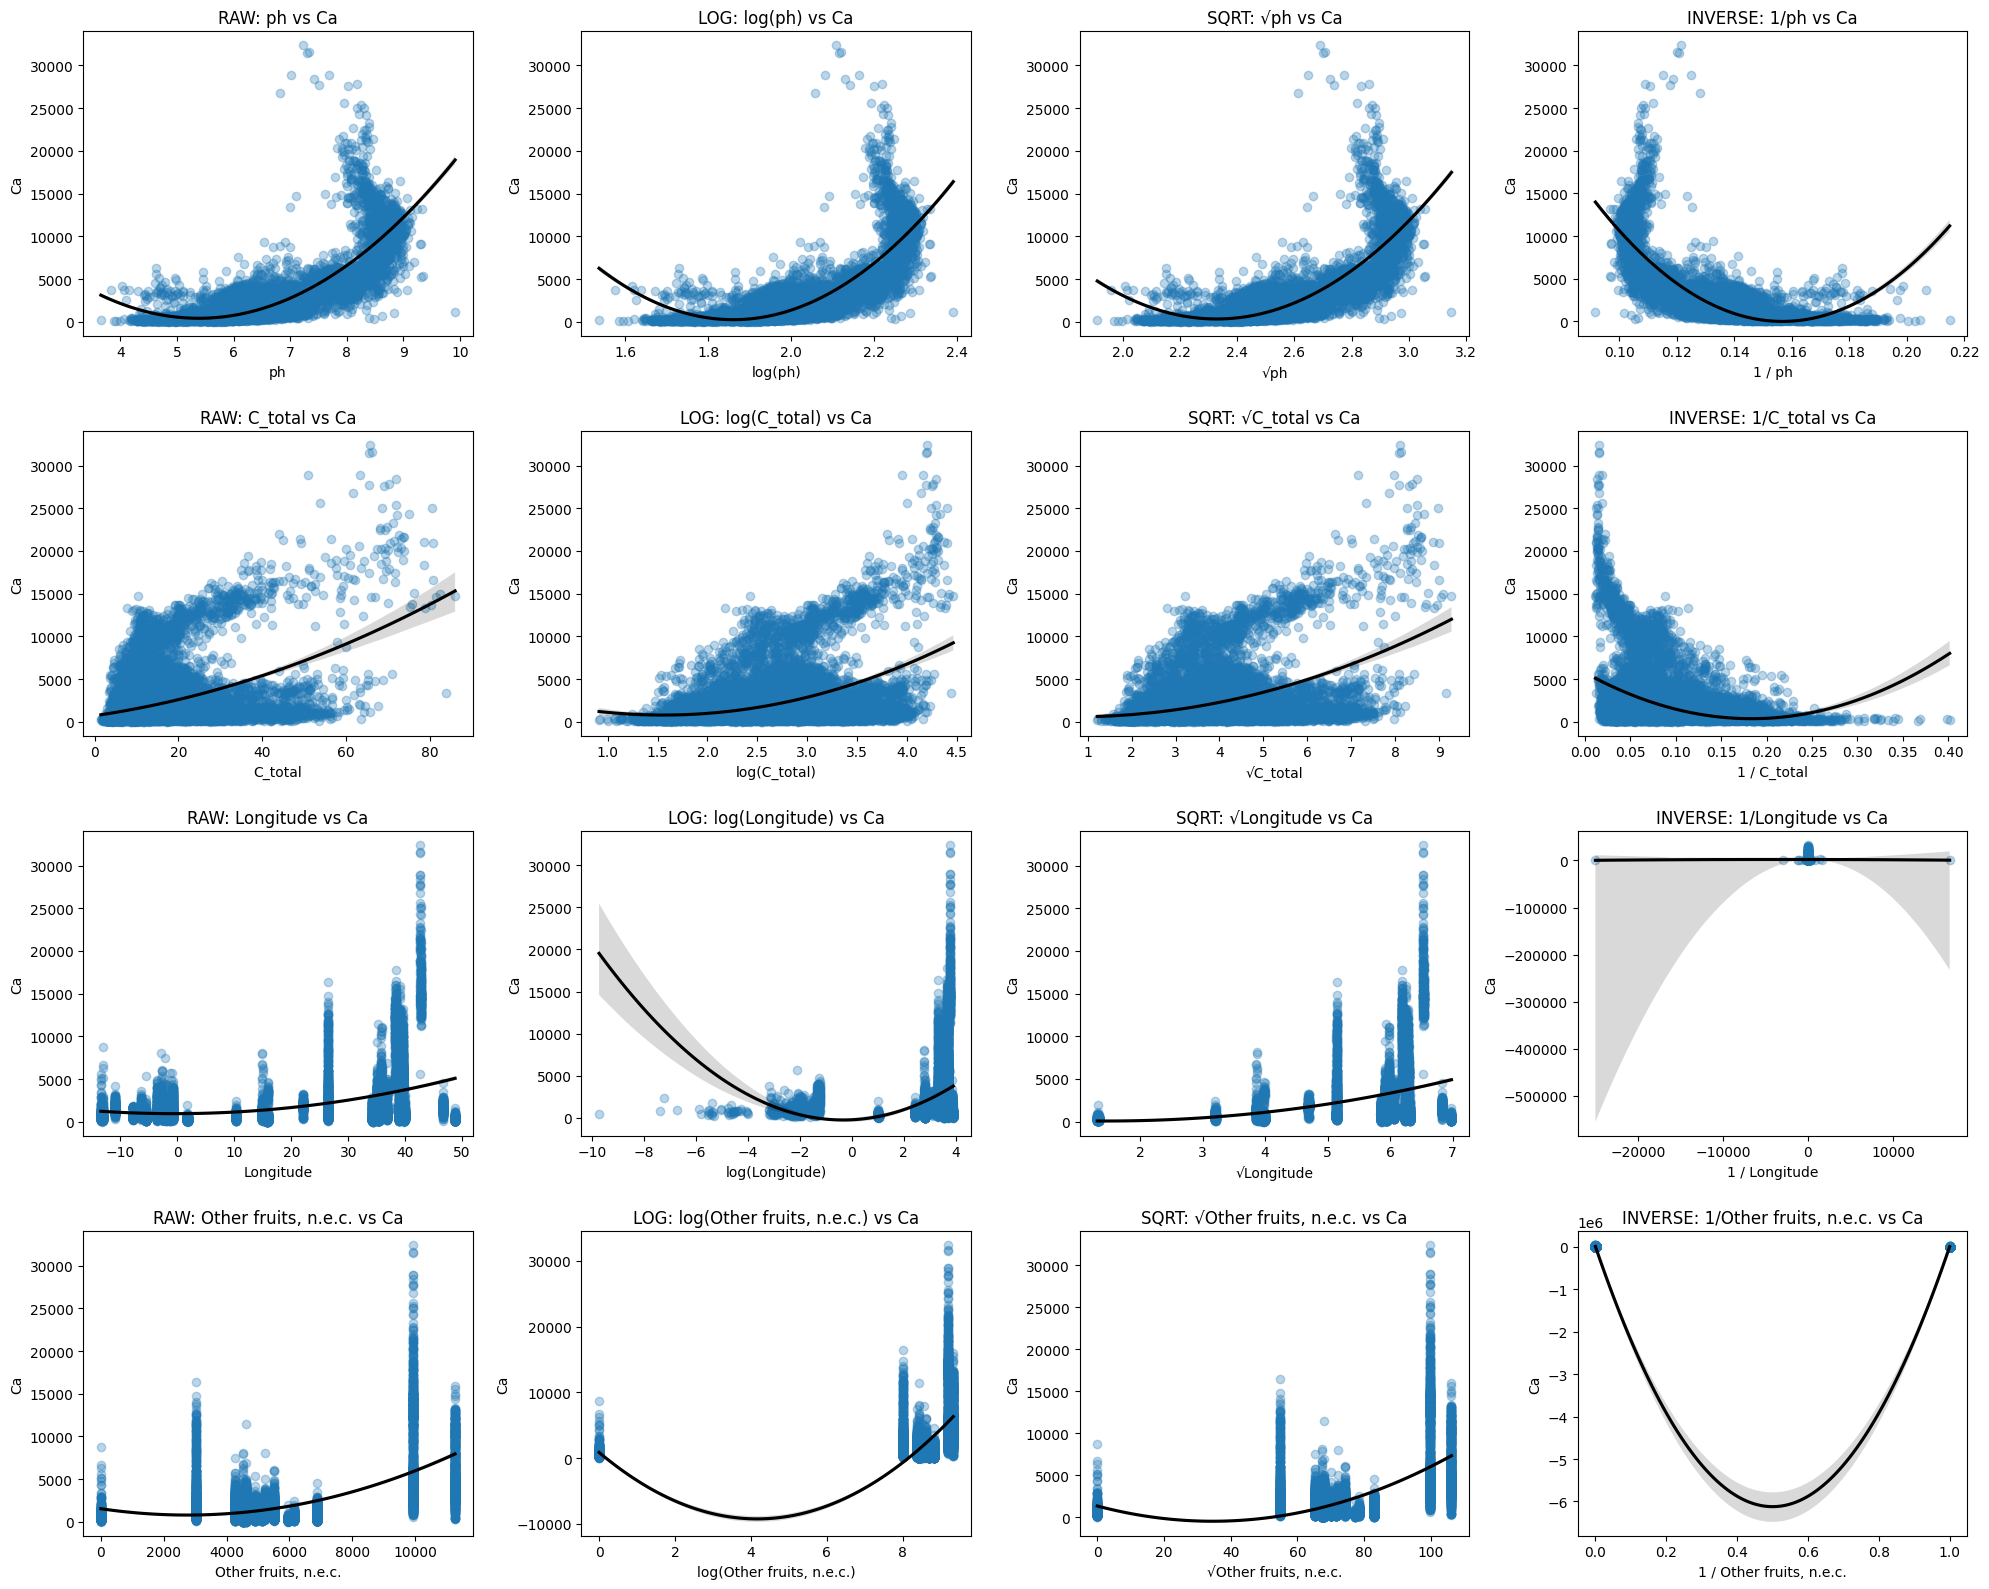

In [58]:
features = ['ph', 'C_total', 'Longitude', 'Other fruits, n.e.c.']
transformations = ['linear', 'sqrt', 'log', 'inverse']
fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for row_idx, col_name in enumerate(features):
    x_data = df[col_name]
    y_data = df['Ca']
    
    sns.regplot(x=x_data, y=y_data, ax=axes[row_idx][0], order=2,
                scatter_kws={'alpha':0.3}, line_kws={'color':'black'})
    axes[row_idx][0].set_title(f"RAW: {col_name} vs Ca")
    axes[row_idx][0].set_xlabel(col_name)
    
    # 2. LOG Transformation (Good for exponential decay/growth)
    # Use np.log1p to avoid log(0) errors
    x_log = np.log1p(x_data)
    sns.regplot(x=x_log, y=y_data, ax=axes[row_idx][1], order=2,
                scatter_kws={'alpha':0.3}, line_kws={'color':'black'})
    axes[row_idx][1].set_title(f"LOG: log({col_name}) vs Ca")
    axes[row_idx][1].set_xlabel(f"log({col_name})")
    
    # 3. SQRT Transformation (Good for weaker power laws)
    x_sqrt = np.sqrt(x_data)
    sns.regplot(x=x_sqrt, y=y_data, ax=axes[row_idx][2], order=2,
                scatter_kws={'alpha':0.3}, line_kws={'color':'black'})
    axes[row_idx][2].set_title(f"SQRT: √{col_name} vs Ca")
    axes[row_idx][2].set_xlabel(f"√{col_name}")

    # 4. INVERSE Transformation (Good for rates/concentrations)
    # Avoid division by zero
    x_inv = 1 / (x_data + 1)
    sns.regplot(x=x_inv, y=y_data, ax=axes[row_idx][3], order=2,
                scatter_kws={'alpha':0.3}, line_kws={'color':'black'})
    axes[row_idx][3].set_title(f"INVERSE: 1/{col_name} vs Ca")
    axes[row_idx][3].set_xlabel(f"1 / {col_name}")

plt.tight_layout()
plt.show()

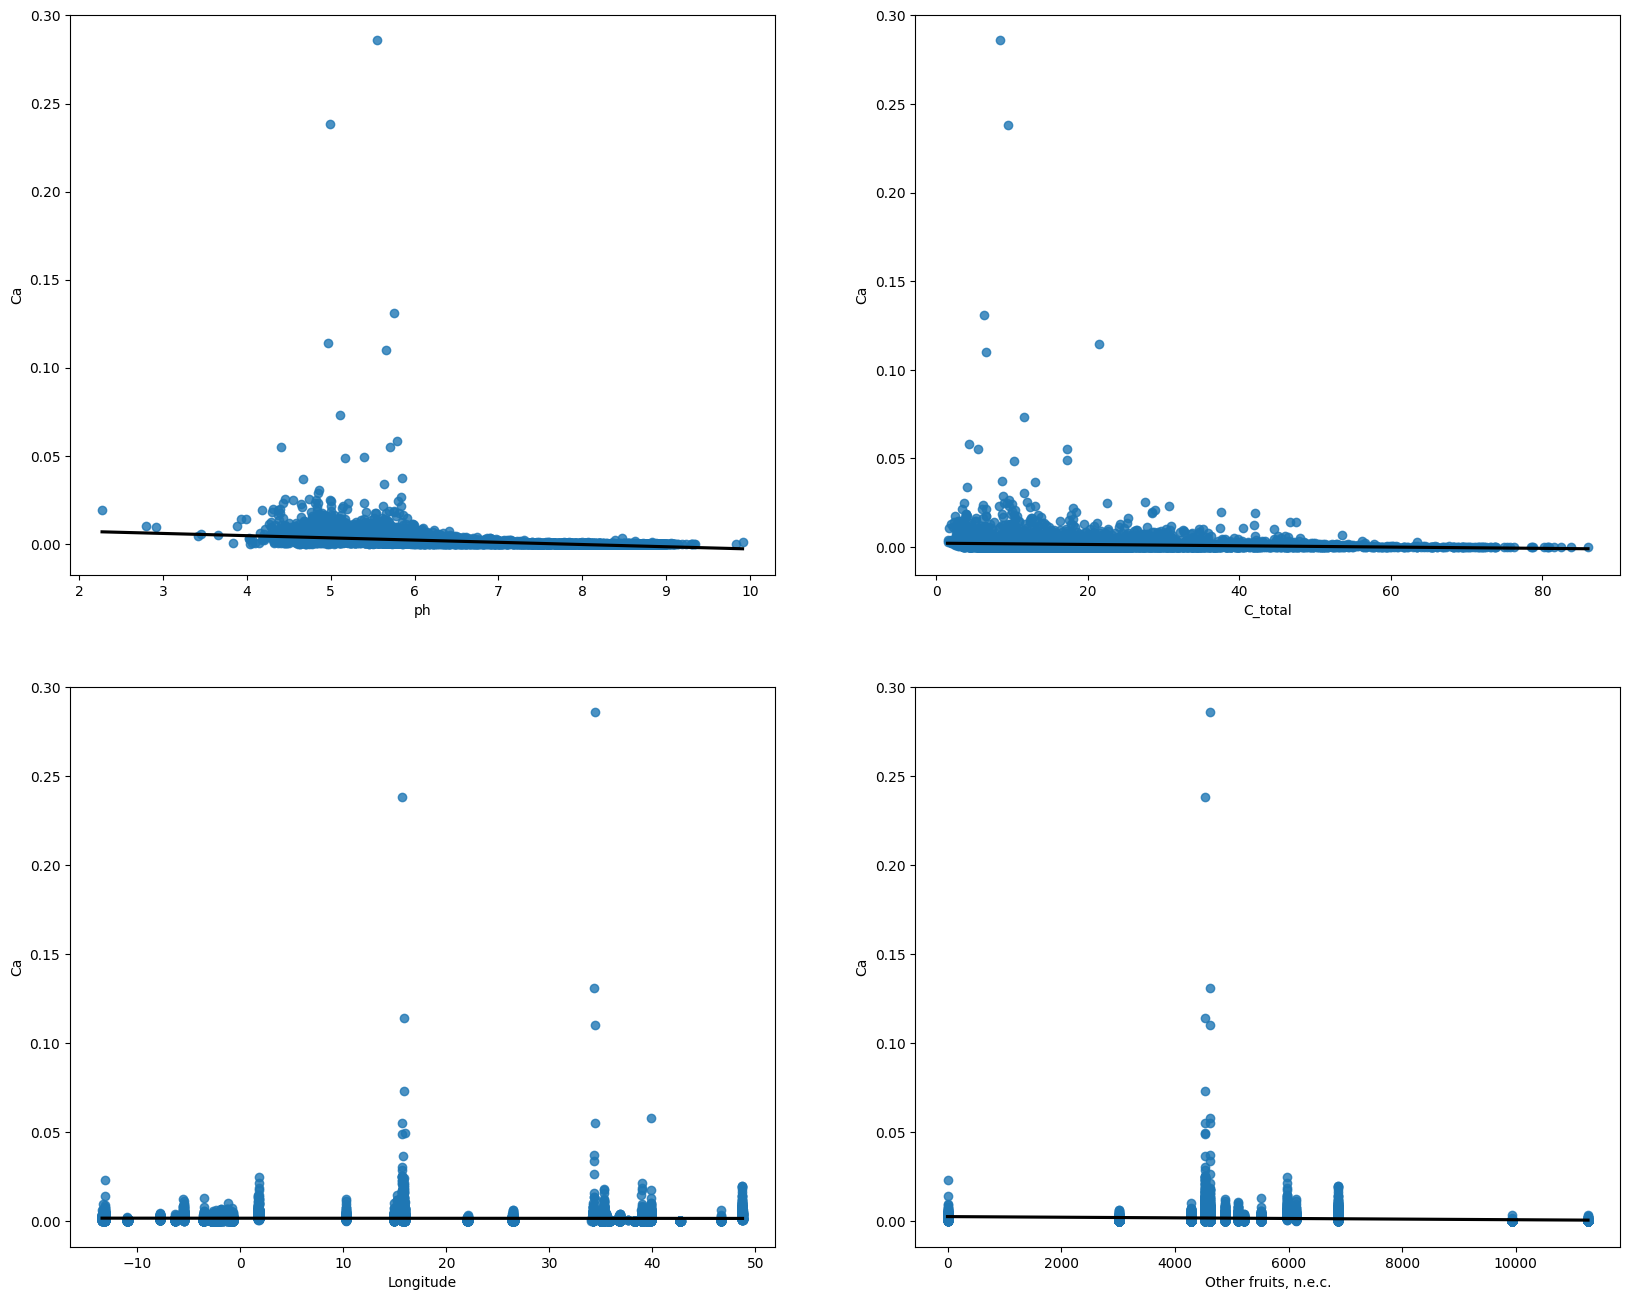

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
y_inv = 1/df['Ca']
sns.regplot(x=df['ph'], y=y_inv, ax=axes[0, 0], line_kws={'color':'black'})
sns.regplot(x=df['C_total'], y=y_inv, ax=axes[0, 1], line_kws={'color':'black'})
sns.regplot(x=df['Longitude'], y=y_inv, ax=axes[1, 0], line_kws={'color':'black'})
sns.regplot(x=df['Other fruits, n.e.c.'], y=y_inv, ax=axes[1, 1], line_kws={'color':'black'})
plt.show()

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x[features], y, test_size=0.2, random_state=42)

In [56]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [57]:
rmse = root_mean_squared_error(y_test, y_pred)
rmse

1413.0457186992226

In [64]:
poly_model = LinearRegression()
poly_model.fit(np.atleast_2d(x_train['ph'] ** 2).reshape(-1, 1), y_train)
y_pred_poly = poly_model.predict(np.atleast_2d(x_test['ph'] ** 2).reshape(-1, 1))

In [65]:
rmse_poly = root_mean_squared_error(y_test, y_pred_poly)
rmse_poly

1818.0991127743375